In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
# 1. Load and Prepare Your Dataset ('data.csv')
# -------------------------------------------------------------
data = pd.read_csv('data.csv')
data.head()  # Display the first few rows of the dataset

,student_id,gender,age,studytime,failures,absences,parent_education,internet,freetime,goout,health,G1,G2,G3
0,1,M,18,2,0,6,high,yes,3,4,3,12,13,13
1,2,F,17,2,0,4,medium,yes,3,3,3,14,15,15
2,3,M,18,3,0,2,high,yes,2,2,5,16,17,17
3,4,F,17,1,1,10,low,no,4,4,4,9,10,10
4,5,M,18,1,2,15,medium,yes,5,5,3,7,8,8


In [4]:
# Clean leading/trailing whitespaces from column headers
data.columns = data.columns.str.strip()

# Convert categorical text columns (e.g., 'M'/'F') into binary numeric indicators
data_encoded = pd.get_dummies(data, drop_first=True, dtype=float)

# Drop rows with missing values
data_encoded = data_encoded.dropna()

# Features (X): all columns except the target
# Target (y): assumed to be the last column in your dataset
X = data_encoded.iloc[:, :-1]
y = data_encoded.iloc[:, -1]

In [5]:
# 2. Train / Test Split & Feature Scaling
# -------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling features is essential for Logistic Regression convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# 3. Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [7]:
# 4. Predict & Evaluate
y_pred = model.predict(X_test_scaled)
y_probs = model.predict_proba(X_test_scaled)[:, 1]  # Probabilities of class 1

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

Accuracy: 100.00%

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         3
         1.0       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



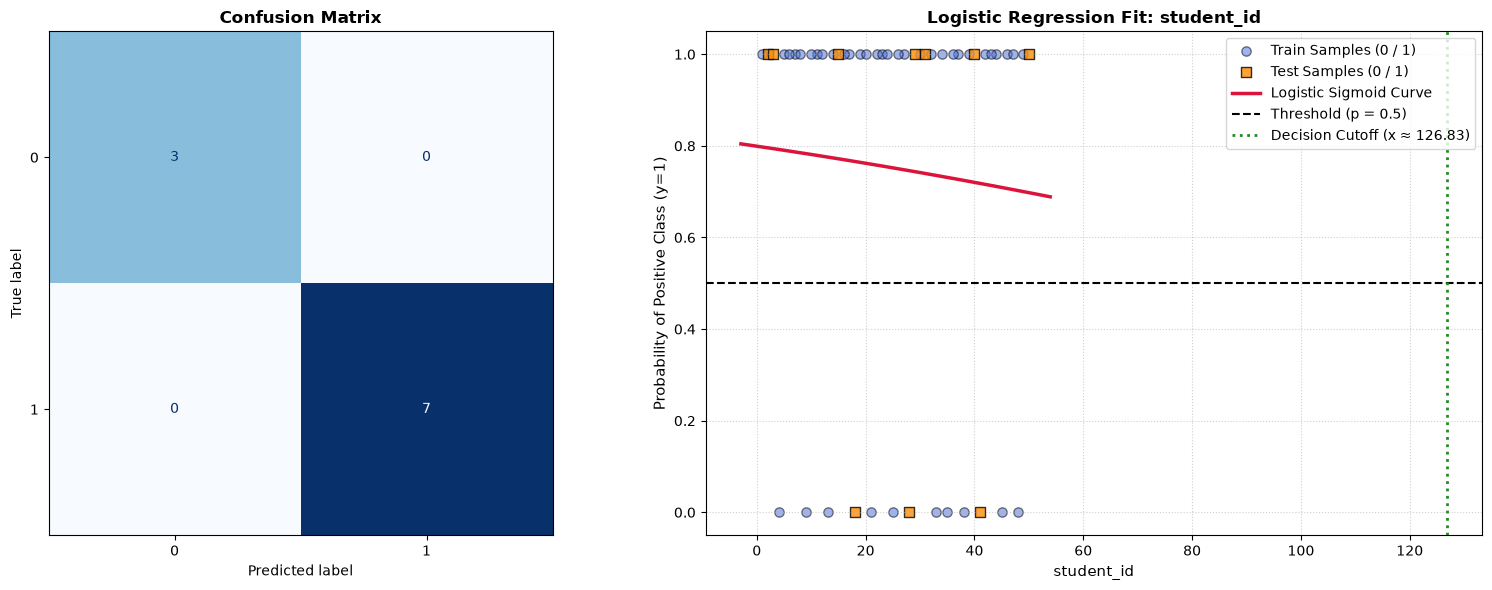

In [12]:
# 5. Visualizations: Confusion Matrix + Sigmoid S-Curve & Linear Boundary
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Confusion Matrix", fontsize=12, fontweight='bold')

# Plot 2: Sigmoid S-Curve using Primary Feature
# Identify the primary continuous feature to display the curve
primary_feature_name = X.columns[0]
feature_idx = 0

# Extract unscaled 1D arrays and flatten them
x_feature_train = np.asarray(X_train.iloc[:, feature_idx]).ravel()
x_feature_test = np.asarray(X_test.iloc[:, feature_idx]).ravel()

# Train a 1D model specifically for generating the continuous 2D boundary curve
model_1d = LogisticRegression()
model_1d.fit(x_feature_train.reshape(-1, 1), y_train)

# Generate smooth points spanning the feature range
x_min, x_max = min(x_feature_train.min(), x_feature_test.min()), max(x_feature_train.max(), x_feature_test.max())
margin = (x_max - x_min) * 0.08
x_smooth = np.linspace(x_min - margin, x_max + margin, 500).reshape(-1, 1)

# Sigmoid probabilities: σ(z)
y_prob_smooth = model_1d.predict_proba(x_smooth)[:, 1]

# Decision cutoff calculation: z = w*x + b = 0 => x = -b/w
w = model_1d.coef_[0][0]
b = model_1d.intercept_[0]
decision_boundary_x = -b / w

# Scatter actual training and testing points
axes[1].scatter(
    x_feature_train, y_train,
    color='royalblue', alpha=0.5, edgecolor='k', s=45, label='Train Samples (0 / 1)'
)
axes[1].scatter(
    x_feature_test, y_test,
    color='darkorange', alpha=0.8, edgecolor='k', s=55, marker='s', label='Test Samples (0 / 1)'
)

# Plot the Sigmoid curve
axes[1].plot(
    x_smooth.ravel(), y_prob_smooth,
    color='crimson', linewidth=2.5, label='Logistic Sigmoid Curve'
)

# Plot Decision Boundary Thresholds
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold (p = 0.5)')
axes[1].axvline(
    decision_boundary_x, color='forestgreen', linestyle=':', linewidth=2,
    label=f'Decision Cutoff (x ≈ {decision_boundary_x:.2f})'
)

axes[1].set_title(f"Logistic Regression Fit: {primary_feature_name}", fontsize=12, fontweight='bold')
axes[1].set_xlabel(primary_feature_name, fontsize=11)
axes[1].set_ylabel("Probability of Positive Class (y=1)", fontsize=11)
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()